<a href="https://colab.research.google.com/github/zygmuntpoludniak/lecture1ZP/blob/regresja/pum4_regresja_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

zaczytanie niezbędnych bibliotek

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

zaczytaj dane dotyczace sprzedazy

In [ ]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "/content/Salary_Data.csv"

# Load the latest version
df = pd.read_csv(file_path)

# Print the first few rows of the DataFrame


print("First 5 records:", df.head())

df.info()

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    fl

preprocessing

1.   sprawdż typy danych
2.   zmien etykiedy na zmienne liczbowe
3. w przypadku brakujacych danych uzupelnij (w przypadku etykiet) najczesciej wystepującą wartością lub średnią wartością



In [ ]:
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])
df['Education Level'] = encoder.fit_transform(df['Education Level'])
df['Job Title'] = encoder.fit_transform(df['Job Title'])

for column in df.columns:
  df[column] = df[column].fillna(df[column].mean())

Podziel zbiór danych na testowy i treningowy w stosunku 30/70

In [ ]:
# prompt: Podziel zbiór danych na testowy i treningowy w stosunku 30/70

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Stworz model regresji liniowej korzystajac z parametrów domyślnych
Przykład dokumentacji: https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py

In [ ]:
# prompt: Stworz model regresji liniowej korzystajac z parametrów domyślnych

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

In [ ]:
# prompt: ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

print("Średni błąd kwadratowy (MSE):", mse)
print("Średni błąd absolutny (MAE):", mae)
print("Wynik wyjaśnionej wariancji (EVS):", evs)


Średni błąd kwadratowy (MSE): 251384617.98392048
Średni błąd absolutny (MAE): 10976.816634914625
Wynik wyjaśnionej wariancji (EVS): 0.8830175673765588


spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

In [ ]:
# prompt: spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Sprawdź korelację między zmiennymi
correlation_matrix = df.corr()
print("Macierz korelacji:\n", correlation_matrix)

# Znormalizuj dane
scaler = StandardScaler()
X = df.drop('Salary', axis=1)
y = df['Salary']

X = scaler.fit_transform(X)




Macierz korelacji:
                           Age    Gender  Education Level  Job Title  \
Age                  1.000000 -0.019865         0.546020   0.116616   
Gender              -0.019865  1.000000         0.008677   0.041562   
Education Level      0.546020  0.008677         1.000000   0.127791   
Job Title            0.116616  0.041562         0.127791   1.000000   
Years of Experience  0.979128  0.002818         0.573355   0.099299   
Salary               0.922335  0.069498         0.650507   0.135033   

                     Years of Experience    Salary  
Age                             0.979128  0.922335  
Gender                          0.002818  0.069498  
Education Level                 0.573355  0.650507  
Job Title                       0.099299  0.135033  
Years of Experience             1.000000  0.930338  
Salary                          0.930338  1.000000  


Zbuduj model regresji odpornej i przetestuj jego predykcje

In [ ]:
# prompt: Zbuduj model regresji odpornej i przetestuj jego predykcje

from sklearn.linear_model import HuberRegressor

# Podziel zbiór danych na testowy i treningowy w stosunku 30/70
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Stwórz model regresji odpornej (HuberRegressor)
huber_regressor = HuberRegressor()
huber_regressor.fit(X_train, y_train)

# Przetestuj predykcje modelu na zbiorze testowym
y_pred_huber = huber_regressor.predict(X_test)

# Ocen model za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji
mse_huber = mean_squared_error(y_test, y_pred_huber)
mae_huber = mean_absolute_error(y_test, y_pred_huber)
evs_huber = explained_variance_score(y_test, y_pred_huber)

print("Wyniki dla regresji odpornej (HuberRegressor):")
print("Średni błąd kwadratowy (MSE):", mse_huber)
print("Średni błąd absolutny (MAE):", mae_huber)
print("Wynik wyjaśnionej wariancji (EVS):", evs_huber)


Wyniki dla regresji odpornej (HuberRegressor):
Średni błąd kwadratowy (MSE): 236917945.1339941
Średni błąd absolutny (MAE): 10782.110995026436
Wynik wyjaśnionej wariancji (EVS): 0.88906349737739


Wykreś przewidziane i faktyczne wartości obu modeli (przykład w dokumentacji: https://scikit-learn.org/stable/auto_examples/ensemble/plot_voting_regressor.html#sphx-glr-auto-examples-ensemble-plot-voting-regressor-py)

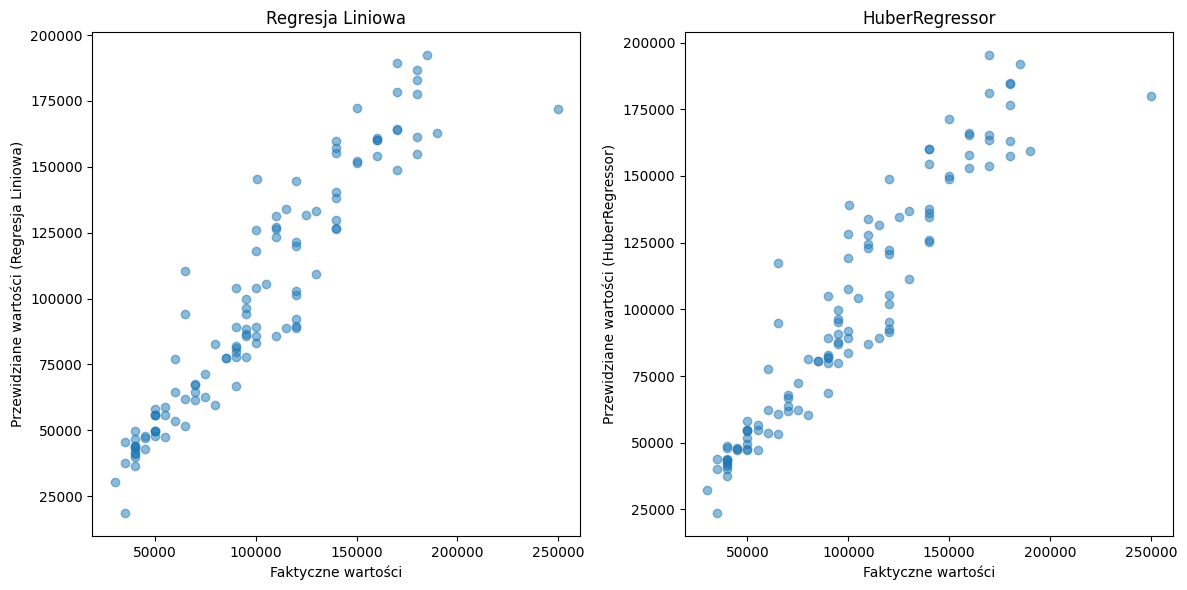

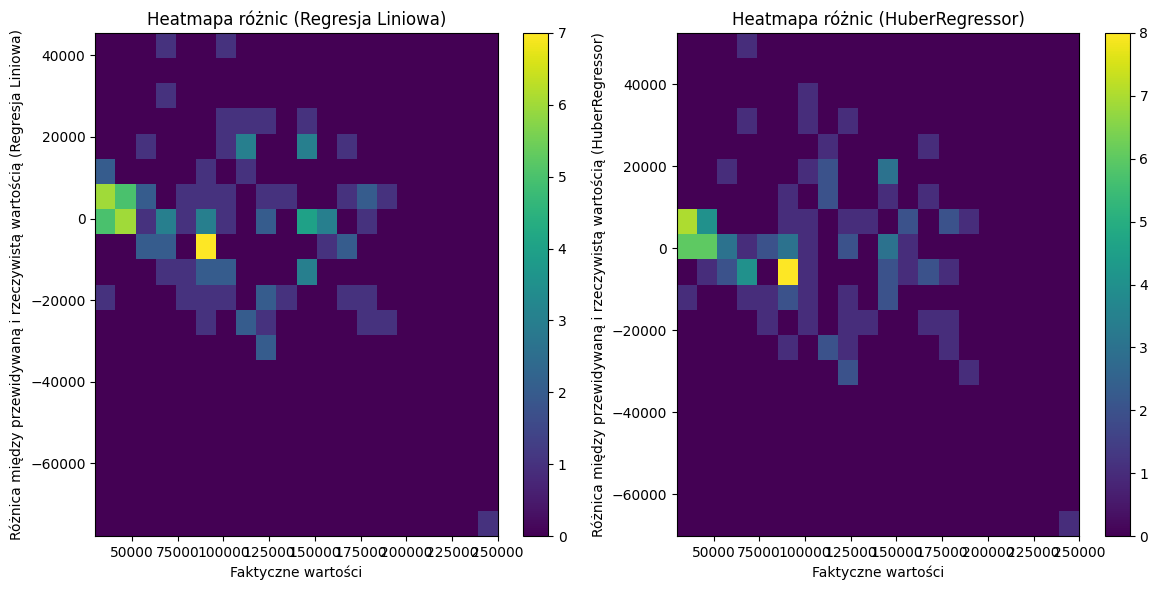

In [ ]:
# prompt: Wykreś przewidziane i faktyczne wartości obu modeli

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, label='Regresja Liniowa', alpha=0.5)
plt.scatter(y_test, y_pred_huber, label='Regresja Odporna (Huber)', alpha=0.5, marker='x')
plt.xlabel('Wartości rzeczywiste')
plt.ylabel('Wartości przewidywane')
plt.title('Porównanie przewidywanych i rzeczywistych wartości dla obu modeli')
plt.legend()
plt.show()


Zmodyfikuj kod, zeby zwizualizować wynik lepszego z modeli

IndexError: index 172 is out of bounds for axis 0 with size 113

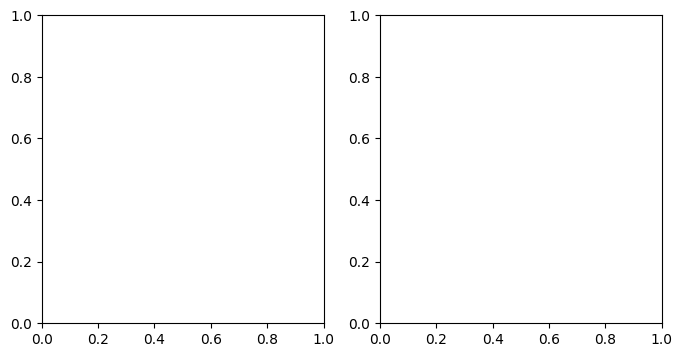

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()